In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette("Blues_d")

# ── Load raw CSVs ──
orders    = pd.read_csv(r"C:\azam\ecommerce\Data\raw\olist_orders_dataset.csv")
items     = pd.read_csv(r"C:\azam\ecommerce\Data\raw\olist_order_items_dataset.csv")
customers = pd.read_csv(r"C:\azam\ecommerce\Data\raw\olist_customers_dataset.csv")
products  = pd.read_csv(r"C:\azam\ecommerce\Data\raw\olist_products_dataset.csv")
payments  = pd.read_csv(r"C:\azam\ecommerce\Data\raw\olist_order_payments_dataset.csv")
reviews   = pd.read_csv(r"C:\azam\ecommerce\Data\raw\olist_order_reviews_dataset.csv")
sellers   = pd.read_csv(r"C:\azam\ecommerce\Data\raw\olist_sellers_dataset.csv")

# ── Load SQL exports ──
monthly_revenue     = pd.read_csv(r"C:\azam\ecommerce\Data\processed\Monthly Revenue Trend.csv")
category_revenue    = pd.read_csv(r"C:\azam\ecommerce\Data\processed\Revenue by Product Category.csv")
customer_by_state   = pd.read_csv(r"C:\azam\ecommerce\Data\processed\Customer Distribution by State.csv")
delivery_perf       = pd.read_csv(r"C:\azam\ecommerce\Data\processed\Delivery Performance Analysis.csv")
payment_breakdown   = pd.read_csv(r"C:\azam\ecommerce\Data\processed\Payment Method Breakdown.csv")
review_scores       = pd.read_csv(r"C:\azam\ecommerce\Data\processed\Customer Review Score Distribution.csv")
rfm                 = pd.read_csv(r"C:\azam\ecommerce\Data\processed\RFM Segmentation (The Impressive One).csv")

print("✅ All files loaded")

✅ All files loaded


In [2]:
raw_files = {
    'orders': orders, 'items': items, 'customers': customers,
    'products': products, 'payments': payments, 'reviews': reviews
}

print("=" * 55)
print(f"{'TABLE':<20} {'ROWS':>8} {'COLS':>6} {'NULLS':>10}")
print("=" * 55)
for name, df in raw_files.items():
    print(f"{name:<20} {df.shape[0]:>8,} {df.shape[1]:>6} {df.isnull().sum().sum():>10,}")
print("=" * 55)

TABLE                    ROWS   COLS      NULLS
orders                 99,441      8      4,908
items                 112,650      7          0
customers              99,441      5          0
products               32,951      9      2,448
payments              103,886      5          0
reviews                99,224      7    145,903


In [3]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Add useful time columns
orders['order_month']    = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
orders['order_year']     = orders['order_purchase_timestamp'].dt.year
orders['order_dayofweek']= orders['order_purchase_timestamp'].dt.day_name()
orders['delivery_days']  = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

print("✅ Date columns fixed")
print(orders[['order_purchase_timestamp','order_month','delivery_days']].head(3))

✅ Date columns fixed
  order_purchase_timestamp order_month  delivery_days
0      2017-10-02 10:56:33     2017-10            8.0
1      2018-07-24 20:41:37     2018-07           13.0
2      2018-08-08 08:38:49     2018-08            9.0


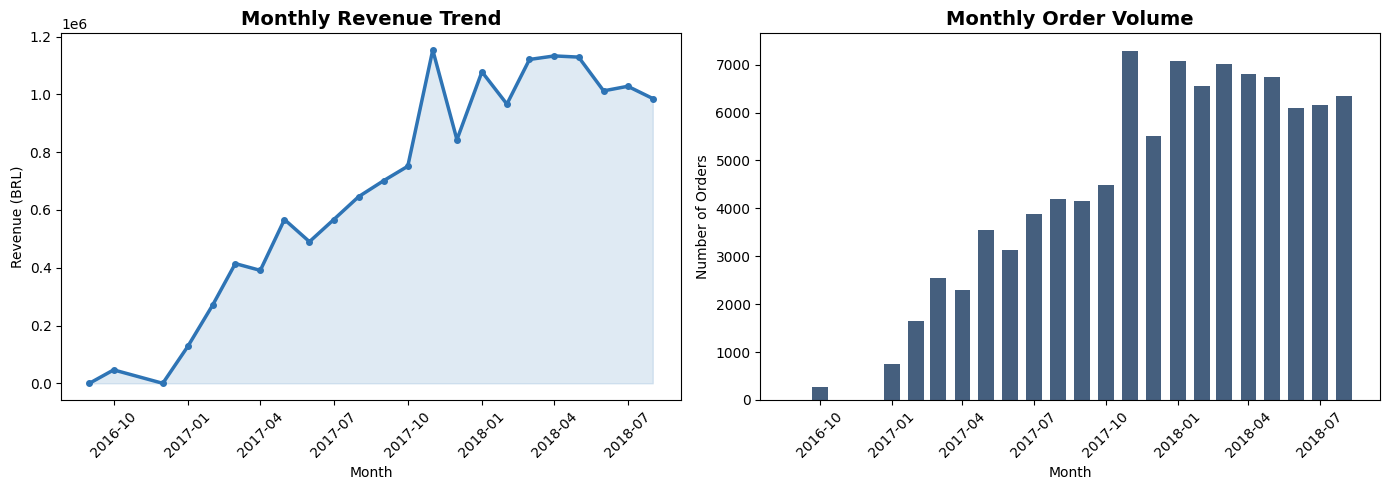


💰 Total Revenue: BRL 15,419,773.75
📈 Peak Month: November 2017


In [6]:
monthly_revenue['month'] = pd.to_datetime(monthly_revenue['month'])
monthly_revenue = monthly_revenue.sort_values('month')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue trend
axes[0].plot(monthly_revenue['month'], monthly_revenue['total_revenue'],
             color='#2E74B5', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(monthly_revenue['month'], monthly_revenue['total_revenue'],
                     alpha=0.15, color='#2E74B5')
axes[0].set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (BRL)')
axes[0].tick_params(axis='x', rotation=45)

# Order volume
axes[1].bar(monthly_revenue['month'], monthly_revenue['total_orders'],
            color='#17375E', alpha=0.8, width=20)
axes[1].set_title('Monthly Order Volume', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('C:/azam/ecommerce/data/processed/revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

total_rev = monthly_revenue['total_revenue'].sum()
peak_month = monthly_revenue.loc[monthly_revenue['total_revenue'].idxmax(), 'month']
print(f"\n💰 Total Revenue: BRL {total_rev:,.2f}")
print(f"📈 Peak Month: {peak_month.strftime('%B %Y')}")

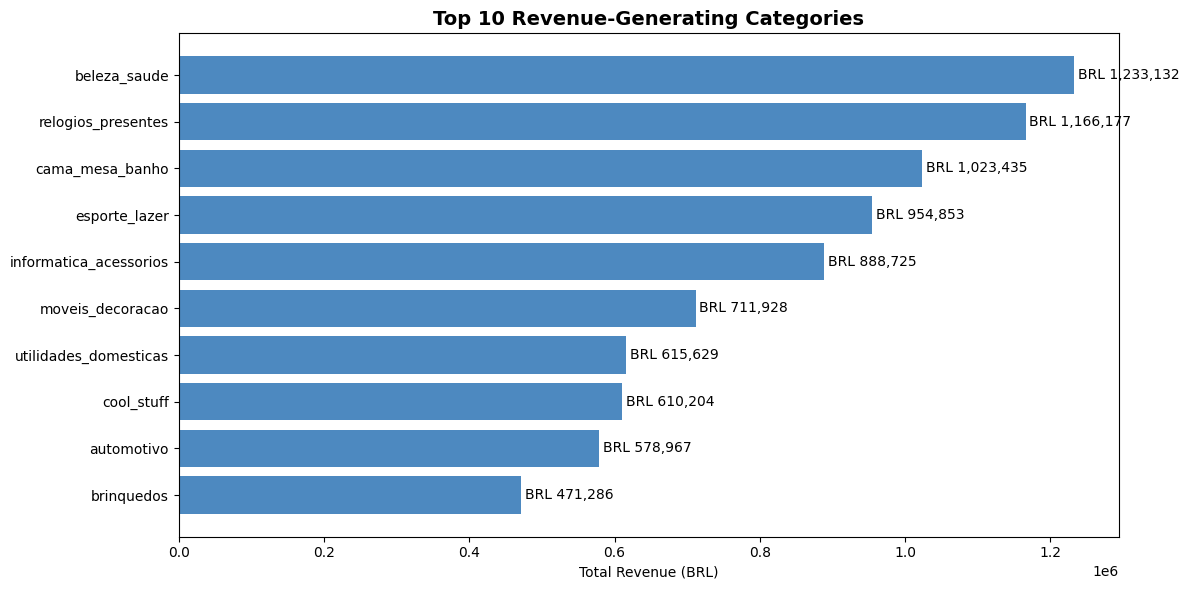

In [7]:
top10 = category_revenue.head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top10['category'], top10['total_revenue'],
                color='#2E74B5', alpha=0.85)

# Add value labels
for bar, val in zip(bars, top10['total_revenue']):
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'BRL {val:,.0f}', va='center', fontsize=10)

plt.xlabel('Total Revenue (BRL)')
plt.title('Top 10 Revenue-Generating Categories', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('C:/azam/ecommerce/data/processed/top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

📦 Delivery Performance Summary
Average delivery time : 12.1 days
Median delivery time  : 10.0 days
Fastest delivery      : 0.0 days
Slowest delivery      : 209.0 days

🚨 Late delivery rate  : 7.9%


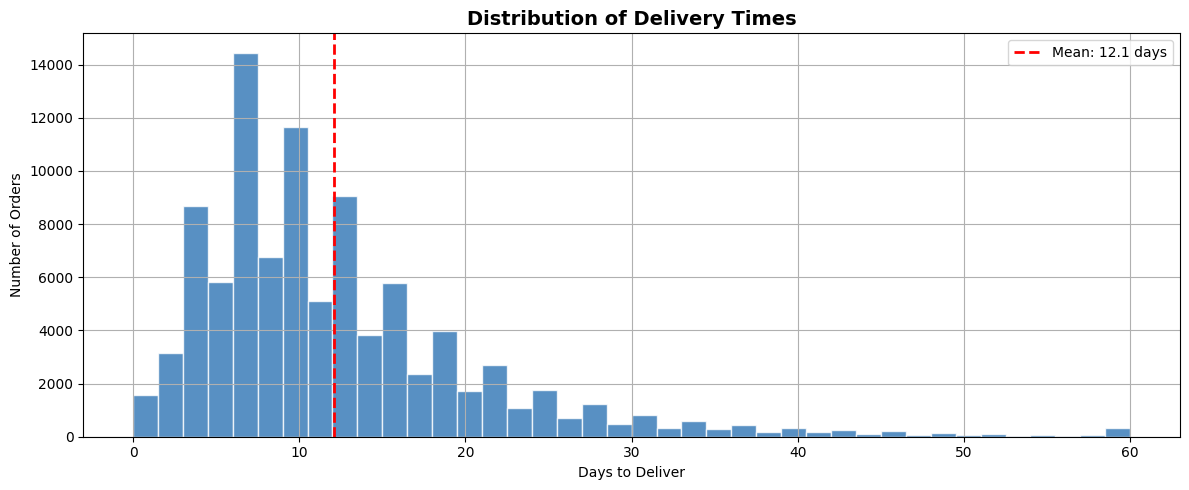

In [8]:
# Overall delivery stats
delivered = orders[orders['order_status'] == 'delivered'].dropna(subset=['delivery_days'])

print("📦 Delivery Performance Summary")
print("=" * 40)
print(f"Average delivery time : {delivered['delivery_days'].mean():.1f} days")
print(f"Median delivery time  : {delivered['delivery_days'].median():.1f} days")
print(f"Fastest delivery      : {delivered['delivery_days'].min()} days")
print(f"Slowest delivery      : {delivered['delivery_days'].max()} days")

# Late delivery rate
late = delivery_perf['late_deliveries'].sum()
total = delivery_perf['total_orders'].sum()
print(f"\n🚨 Late delivery rate  : {late/total*100:.1f}%")

# Plot delivery days distribution
plt.figure(figsize=(12, 5))
delivered['delivery_days'].clip(0, 60).hist(bins=40, color='#2E74B5',
                                             alpha=0.8, edgecolor='white')
plt.axvline(delivered['delivery_days'].mean(), color='red',
            linestyle='--', linewidth=2, label=f"Mean: {delivered['delivery_days'].mean():.1f} days")
plt.title('Distribution of Delivery Times', fontsize=14, fontweight='bold')
plt.xlabel('Days to Deliver')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.savefig('C:/azam/ecommerce/data/processed/delivery_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

👥 RFM Customer Segments
Segment                 Customers   Total Revenue
At Risk                    18,112    9,225,808.42
Potential Loyalists        32,689    8,114,175.72
Loyal Customers            23,028    7,806,831.12
Lost Customers              4,325    3,773,501.50
Champions                  15,204    1,919,230.74


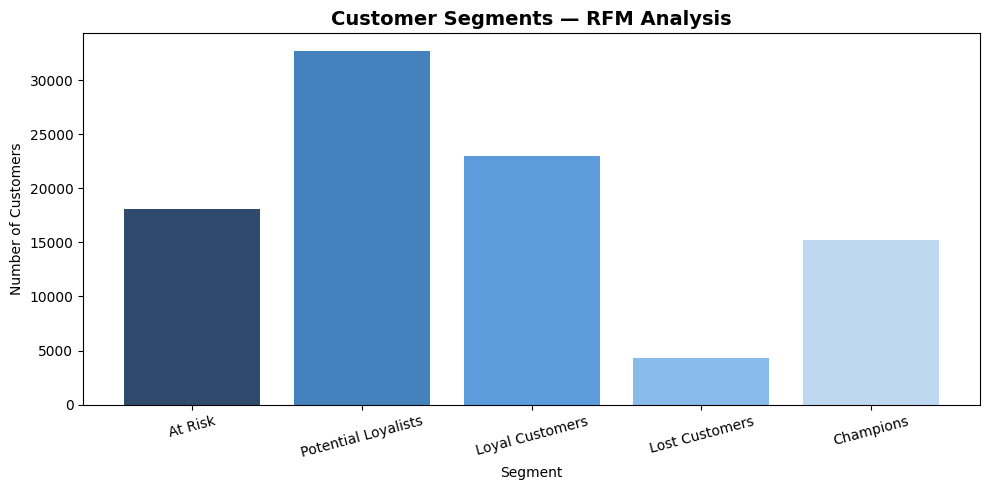

In [9]:
seg_counts = rfm['customer_segment'].value_counts().reset_index()
seg_counts.columns = ['segment', 'count']
seg_revenue = rfm.groupby('customer_segment')['monetary'].sum().reset_index()
seg_revenue.columns = ['segment', 'total_revenue']
seg_summary = seg_counts.merge(seg_revenue, on='segment').sort_values('total_revenue', ascending=False)

print("👥 RFM Customer Segments")
print("=" * 55)
print(f"{'Segment':<22} {'Customers':>10} {'Total Revenue':>15}")
print("=" * 55)
for _, row in seg_summary.iterrows():
    print(f"{row['segment']:<22} {row['count']:>10,} {row['total_revenue']:>15,.2f}")

colors = ['#17375E','#2E74B5','#4A90D9','#7BB3E8','#B8D4F0']
plt.figure(figsize=(10, 5))
plt.bar(seg_summary['segment'], seg_summary['count'], color=colors, alpha=0.9)
plt.title('Customer Segments — RFM Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('C:/azam/ecommerce/data/processed/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Master orders table ──
master = (
    orders[orders['order_status'] == 'delivered']
    .merge(items[['order_id','product_id','price','freight_value','seller_id']], on='order_id')
    .merge(customers[['customer_id','customer_state','customer_city']], on='customer_id')
    .merge(products[['product_id','product_category_name']], on='product_id', how='left')
    .merge(payments[['order_id','payment_type','payment_value']]
           .drop_duplicates('order_id'), on='order_id', how='left')
)

master['total_order_value'] = master['price'] + master['freight_value']
master['order_month']       = master['order_purchase_timestamp'].dt.to_period('M').astype(str)
master['order_year']        = master['order_purchase_timestamp'].dt.year
master['order_quarter']     = master['order_purchase_timestamp'].dt.quarter

# ── Export all tables ──
master.to_csv('C:/azam/ecommerce/data/processed/master_orders.csv', index=False)
rfm.to_csv('C:/azam/ecommerce/data/processed/rfm_final.csv', index=False)
delivery_perf.to_csv('C:/azam/ecommerce/data/processed/delivery_final.csv', index=False)

print(f"✅ master_orders.csv  → {master.shape[0]:,} rows, {master.shape[1]} columns")
print(f"✅ rfm_final.csv      → {rfm.shape[0]:,} rows")
print(f"✅ delivery_final.csv → {delivery_perf.shape[0]:,} rows")
print("\n🎉 Phase 2 Complete — Ready for Power BI!")

✅ master_orders.csv  → 110,197 rows, 23 columns
✅ rfm_final.csv      → 93,358 rows
✅ delivery_final.csv → 27 rows

🎉 Phase 2 Complete — Ready for Power BI!
